In [6]:
!pip install seaborn

                                              0.0/294.9 kB ? eta -:--:--
     --------------------------             204.8/294.9 kB 4.1 MB/s eta 0:00:01
     -------------------------------------- 294.9/294.9 kB 4.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.1.2 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [63]:
import pandas as pd
data = pd.read_csv('./stroke-dataset.csv')
data.loc[162]

id                      69768
gender                 Female
age                      1.32
hypertension                0
heart_disease               0
ever_married               No
work_type            children
Residence_type          Urban
avg_glucose_level       70.37
bmi                       NaN
smoking_status        Unknown
stroke                      1
Name: 162, dtype: object

In [55]:
pd.factorize(data['work_type'])

(array([0, 1, 0, ..., 1, 0, 2]),
 Index(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'], dtype='object'))

In [71]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn import set_config

set_config(transform_output="default")

nominal_columns = ['work_type']
ordinal_or_binary_columns = ['Residence_type', 'gender', 'ever_married', 'smoking_status']
irrelevant_columns = ['id']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Rural', 'Urban'],
    ['Male', 'Female', 'Other'],
    ['No', 'Yes'],
    ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
])

feature_encoder = make_column_transformer(
    (OneHotEncoder(), nominal_columns),
    (ordinal_encoder, ordinal_or_binary_columns),
    #('drop', irrelevant_columns),
    remainder='passthrough'
)

X = data.drop(['stroke'], axis=1)
y = data['stroke']

X_encoded = feature_encoder.fit_transform(X)
X = X.drop(['id'], axis=1)
encoded_data = pd.DataFrame(data=X_encoded, index=X.index, columns=['work_type_government_job', 'work_type_never_worked', 'work_type_private', 'work_type_self_employed', 'work_type_children', 'Residence_type', 'gender', 'ever_married', 'smoking_status', 'id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'] )
encoded_data['stroke'] = y
encoded_data = encoded_data.drop(['id'], axis=1)
encoded_data

,work_type_government_job,work_type_never_worked,work_type_private,work_type_self_employed,work_type_children,Residence_type,gender,ever_married,smoking_status,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,2.0,67.0,0.0,1.0,228.69,36.6,1
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,61.0,0.0,0.0,202.21,NaN,1
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,80.0,0.0,1.0,105.92,32.5,1
3,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,3.0,49.0,0.0,0.0,171.23,34.4,1
4,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,79.0,1.0,0.0,174.12,24.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,80.0,1.0,0.0,83.75,NaN,0
5106,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,81.0,0.0,0.0,125.20,40.0,0
5107,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,35.0,0.0,0.0,82.99,30.6,0
5108,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.0,51.0,0.0,0.0,166.29,25.6,0


In [72]:
encoded_data.corr()

,work_type_government_job,work_type_never_worked,work_type_private,work_type_self_employed,work_type_children,Residence_type,gender,ever_married,smoking_status,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
work_type_government_job,1.000000,-0.025258,-0.444420,-0.167810,-0.151383,0.013131,0.016369,0.134041,0.075414,0.130013,0.017685,0.001330,0.013845,0.079584,0.002677
work_type_never_worked,-0.025258,1.000000,-0.076081,-0.028728,-0.025915,0.022859,-0.011513,-0.090838,-0.034701,-0.078653,-0.021608,-0.015712,-0.014675,-0.028602,-0.014882
work_type_private,-0.444420,-0.076081,1.000000,-0.505475,-0.455992,-0.018173,0.032959,0.153830,0.173209,0.116534,-0.005413,0.000027,0.016588,0.208029,0.011888
work_type_self_employed,-0.167810,-0.028728,-0.505475,1.000000,-0.172180,0.010594,0.025778,0.192716,0.079098,0.327989,0.115442,0.086760,0.062694,0.072701,0.062168
work_type_children,-0.151383,-0.025915,-0.455992,-0.172180,1.000000,-0.002309,-0.089374,-0.544441,-0.403603,-0.634215,-0.129506,-0.091634,-0.102250,-0.448674,-0.083869
Residence_type,0.013131,0.022859,-0.018173,0.010594,-0.002309,1.000000,0.005529,0.006261,0.022853,0.014180,-0.007913,0.003092,-0.004946,-0.000122,0.015458
gender,0.016369,-0.011513,0.032959,0.025778,-0.089374,0.005529,1.000000,0.029366,0.003157,0.027300,-0.021390,-0.085749,-0.054213,0.025658,-0.009200
ever_married,0.134041,-0.090838,0.153830,0.192716,-0.544441,0.006261,0.029366,1.000000,0.284833,0.679125,0.164243,0.114644,0.155068,0.341695,0.108340
smoking_status,0.075414,-0.034701,0.173209,0.079098,-0.403603,0.022853,0.003157,0.284833,1.000000,0.307009,0.106639,0.085211,0.079825,0.222564,0.054914
age,0.130013,-0.078653,0.116534,0.327989,-0.634215,0.014180,0.027300,0.679125,0.307009,1.000000,0.276398,0.263796,0.238171,0.333398,0.245257


<Axes: >

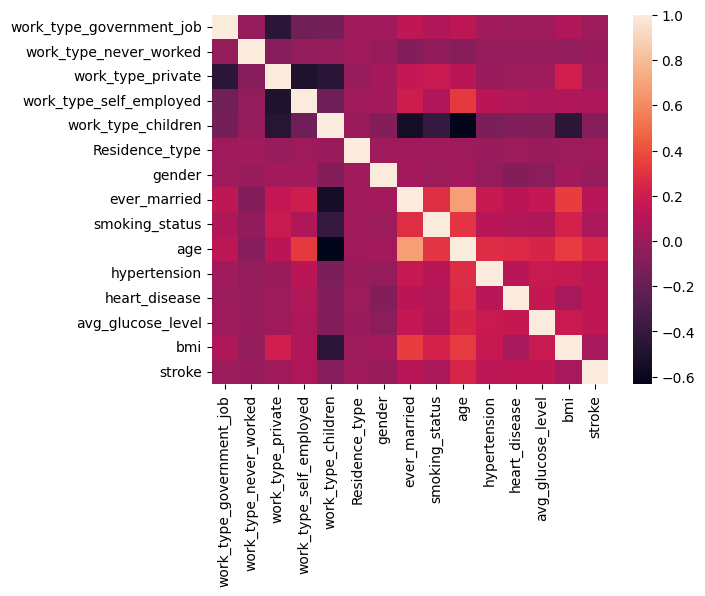

In [73]:
import seaborn as sns

sns.heatmap(encoded_data.corr())